# Современные библиотеки градиентного бустинга

В этом блокноте мы рассмотрим некоторые современные модели, как развитие идей наивной версии [градиентного бустинга](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) из scikit-learn, [придуманную](https://projecteuclid.org/download/pdf_1/euclid.aos/1013203451) в 1999 году Фридманом. С тех пор было предложено много реализаций, которые оказываются лучше на практике. На сегодняшний день популярны три библиотеки, реализующие градиентный бустинг:
* **XGBoost**. После выхода быстро набрала популярность и оставалась стандартом до конца 2016 года. Одними из основных особенностей имплементации были оптимизированность построения деревьев, а также различные регуляризации модели.
* **LightGBM**. Отличительной чертой является быстрота построения композиции. Например, используется следующий трюк для ускорения обучения: при построении вершины дерева вместо перебора по всем значениям признака производится перебор значений гистограммы этого признака. Таким образом, вместо $O(\ell)$ требуется $O(\text{#bins})$. Кроме того, в отличие от других библиотек, которые строят дерево по уровням, LightGBM использует стратегию best-first, т.е. на каждом шаге строит вершину, дающую наибольшее уменьшение функционала. Таким образом, каждое дерево является цепочкой с прикрепленными листьями.
* **CatBoost**. Библиотека от компании Яндекс. Позволяет автоматически обрабатывать категориальные признаки (даже если их значения представлены в виде строк). Кроме того, алгоритм является менее чувствительным к выбору конкретных гиперпараметров. За счёт этого уменьшается время, которое тратит человек на подбор оптимальных гиперпараметров.

## Описание основных параметров

(lightgbm/catboost)

* `objective` – функционал, на который будет настраиваться композиция
* `eta` / `learning_rate` – темп (скорость) обучения
* `num_iterations` / `n_estimators`  – число итераций бустинга

#### Параметры, отвечающие за сложность деревьев
* `max_depth` – максимальная глубина
* `max_leaves` / num_leaves – максимальное число вершин в дереве
* `gamma` / `min_gain_to_split` – порог на уменьшение функции ошибки при расщеплении в дереве
* `min_data_in_leaf` – минимальное число объектов в листе
* `min_sum_hessian_in_leaf` – минимальная сумма весов объектов в листе, минимальное число объектов, при котором делается расщепление
* `lambda` – коэффициент регуляризации (L2)
* `subsample` / `bagging_fraction` – какую часть объектов обучения использовать для построения одного дерева
* `colsample_bytree` / `feature_fraction` – какую часть признаков использовать для построения одного дерева

Подбор всех этих параметров — настоящее искусство. Но начать их настройку можно с самых главных параметров: `learning_rate` и `n_estimators`. Обычно один из них фиксируют, а оставшийся из этих двух параметров подбирают (например, фиксируют `n_estimators=1000` и подбирают `learning_rate`). Следующим по важности является `max_depth`. В силу того, что мы заинтересованы в неглубоких деревьях, обычно его перебирают из диапазона [3; 7].

# Практические эксперименты

# Подготовка данных

Установим и импортируем необходимые библиотеки

In [ ]:
!pip install -q catboost
!pip install -q lightgbm
!pip install -q xgboost
!pip install -q mlxtend
!pip install -q dask[dataframe]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import f1_score
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

Сгенерируем наборы данных. Рассмотрим данные разной структуры для того, чтобы более наглядно сравнить рассматриваемые модели.

In [ ]:
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)

# Datasets
linearly_separable = (X, y)
moons = make_moons(noise=0.3, random_state=0)
circles = make_circles(noise=0.2, factor=0.5, random_state=1)

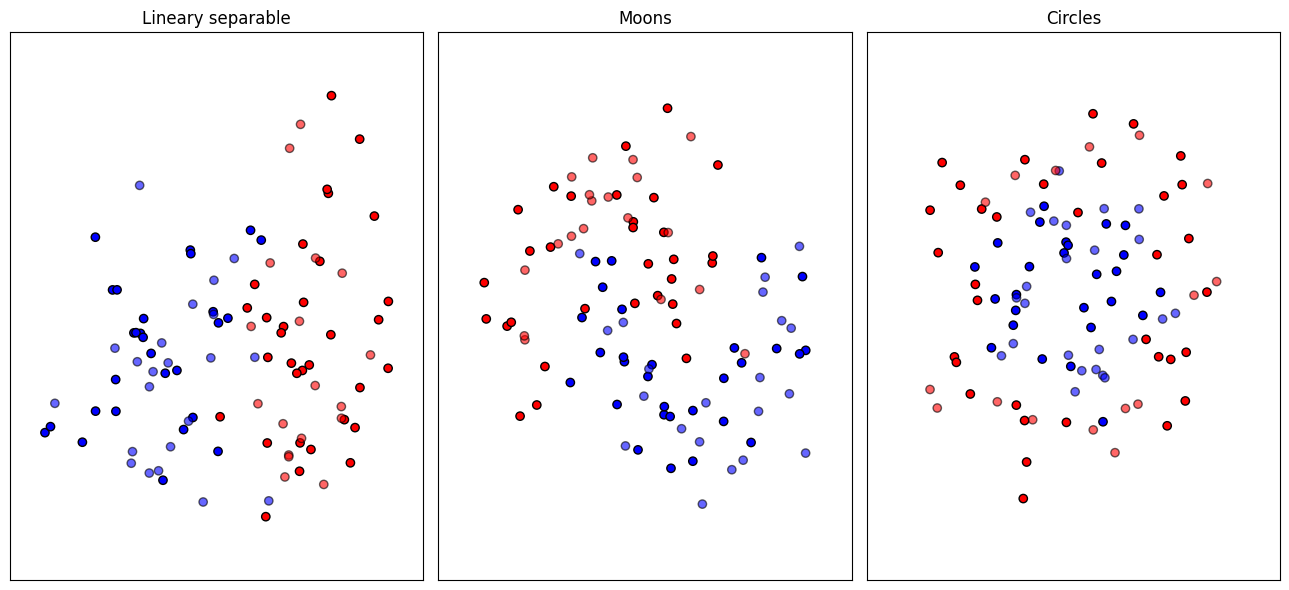

In [ ]:
# Plotting
figure = plt.figure(figsize=(13, 6))
cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])
titles = ['Lineary separable', 'Moons', 'Circles']

for i, ds in enumerate([linearly_separable, moons, circles]):
    plt.subplot(1, 3, i + 1)
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])
plt.tight_layout()
plt.show()

# Внутренняя структура данных

Рассмотрим, как анализируемые модели "справляются" с данным различной "формы". Для рассмотренных выше наборов данных: `linearly_separable, moons, circles`:
1. Разбейте на трейн/тест со следующими параметрами `test_size=0.4, random_state=42`.
2. Обучите на трейне, оцените на тесте модели `XGBClassifier, LGBMClassifier,
    CatBoostClassifier`
3. Нарисуйте `DecisionBoundaryDisplay.from_estimator(clf, X, cmap=cm, alpha=0.8, eps=0.5)`
4. При помощи `scatterplot` нарисуйте тренировочные и тестовые данные. Тестовые с `alpha=0.6`.
5. Интерпретируйте полученные результаты

### XGBClassifier

Accuracy:  0.725


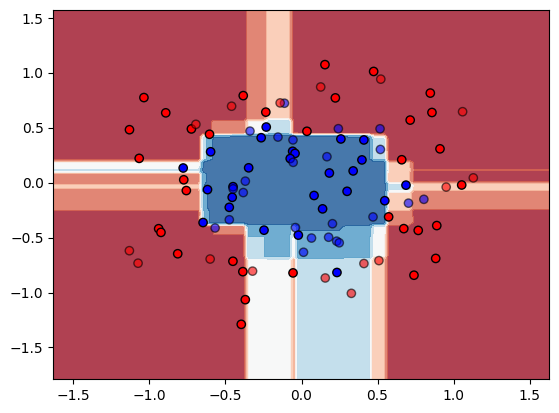

In [ ]:
# YOUR CODE HERE

#P.S. Для каждого набора данных и каждого классификатора должно получиться что то типа
xgb = XGBClassifier()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
xgb.fit(X_train,y_train)
print('Accuracy: ', xgb.score(X_test, y_test))
DecisionBoundaryDisplay.from_estimator(xgb, X, cmap=cm, alpha=0.8, eps=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")

### LGBMClassifier

Accuracy:  0.55


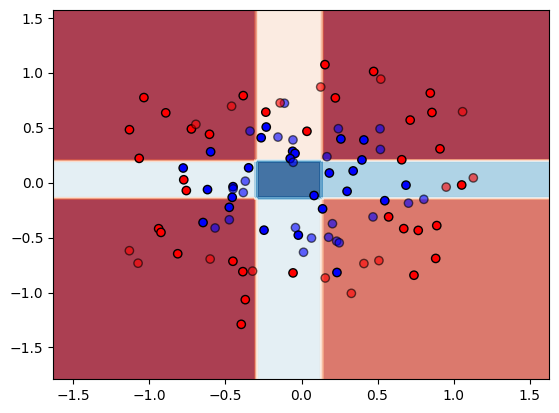

In [ ]:
# YOUR CODE HERE
lgbm = LGBMClassifier(verbose=-1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
lgbm.fit(X_train,y_train)
print('Accuracy: ', lgbm.score(X_test, y_test))
DecisionBoundaryDisplay.from_estimator(lgbm, X, cmap=cm, alpha=0.8, eps=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")

### CatBoostClassifier

Accuracy:  0.775


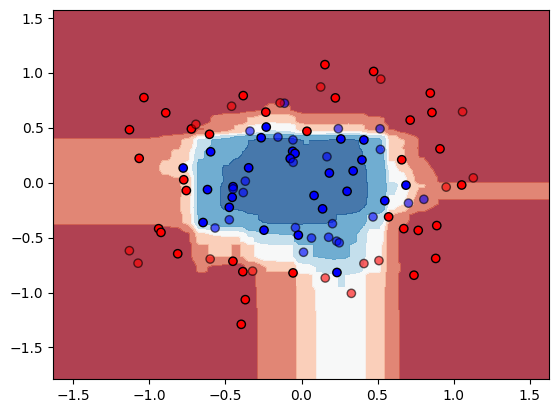

In [ ]:
# YOUR CODE HERE
cat = CatBoostClassifier(verbose=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
cat.fit(X_train,y_train)
print('Accuracy: ', cat.score(X_test, y_test))
DecisionBoundaryDisplay.from_estimator(cat, X, cmap=cm, alpha=0.8, eps=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")

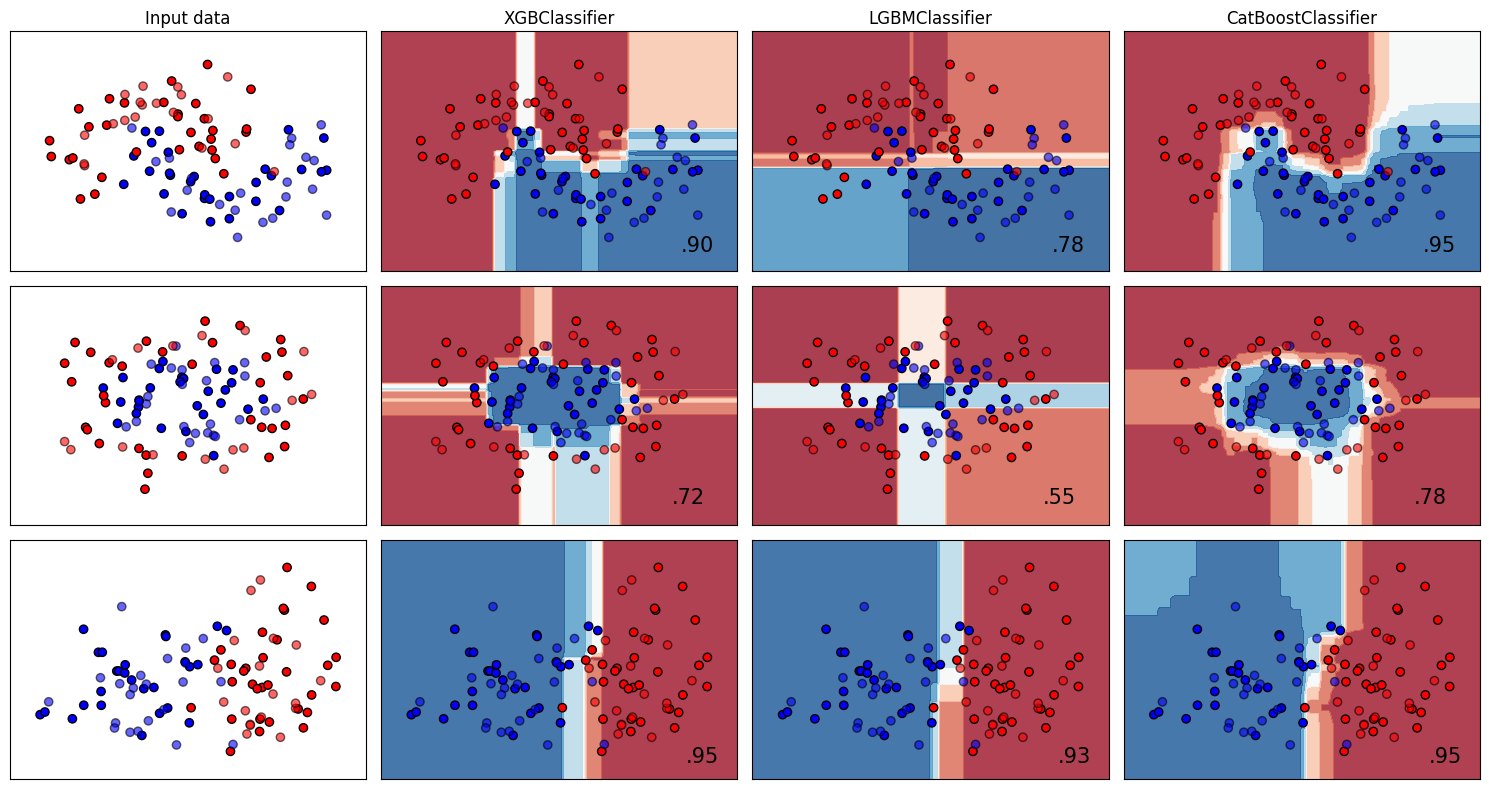

In [ ]:
# @title Все результаты
names = [
    "XGBClassifier",
    "LGBMClassifier",
    "CatBoostClassifier"
]

classifiers = [
XGBClassifier(),
LGBMClassifier(verbose=-1),
CatBoostClassifier(verbose=0)
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]

figure = plt.figure(figsize=(15, 8))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

# Подбор параметров

Видно, что в случае `LGBM` модель получается достаточно простой и не описывает рассматриваемых зависимостей. Наверное имеет смысл подобрать параметры.

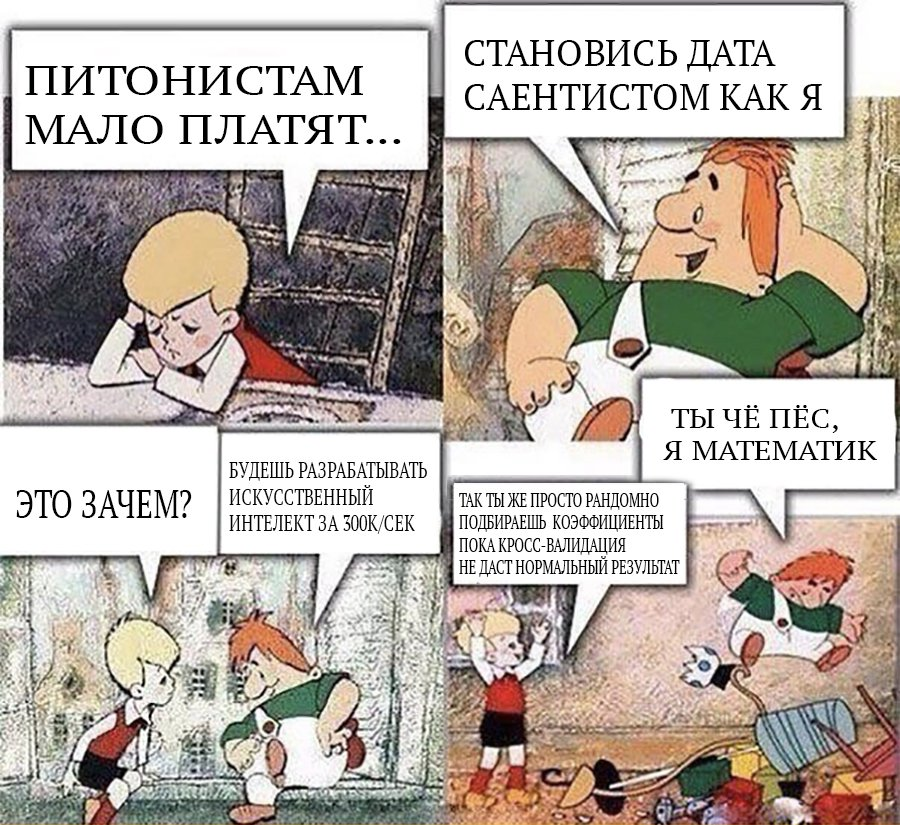

Accuracy:  0.725


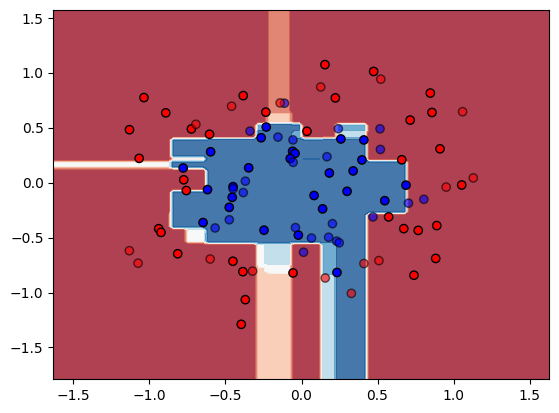

In [ ]:
X, y = circles
lgbm =  LGBMClassifier(
    num_leaves=127,           # ↑ Увеличить (default=31)
    max_depth=10,             # ↑ Ограничить глубину
    min_data_in_leaf=5,       # ↓ Уменьшить (default=20)
    min_gain_to_split=0.0,    # ↓ Разрешить любые разбиения
    lambda_l1=0.0,            # ↓ Убрать регуляризацию
    lambda_l2=0.0,            # ↓ Убрать регуляризацию
    n_estimators=500,         # ↑ Больше деревьев
    learning_rate=0.05,       # ↓ Меньше шаг
    max_bin=512               # ↑ Больше bins для точности (default=255)
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
lgbm.fit(X_train,y_train)
print('Accuracy: ', lgbm.score(X_test, y_test))
DecisionBoundaryDisplay.from_estimator(lgbm, X, cmap=cm, alpha=0.8, eps=0.5)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")

# Проверим на соревновании

Будем использовать другой датасет

In [ ]:
!unzip /content/train.csv.zip

In [ ]:
import pandas as pd

data = pd.read_csv("/content/train.csv")
data = data.drop(["generation", "complectation", "address", "options", "description", "id"], axis=1)

In [ ]:
data.isnull().sum()

,0
price_rub,0
mark,0
model,0
configuration,0
body_type,0
color,7
displacement,0
drive_type,0
engine_type,0
horse_power,0


In [ ]:
for_prediction = pd.read_csv("/content/test.csv", index_col='id')
for_prediction = for_prediction.drop(["generation", "complectation", "address", "options", "description"], axis=1)
for_prediction.head()

,mark,model,configuration,body_type,color,displacement,drive_type,engine_type,horse_power,transmission,wheel,km_age,year,owners_count,condition,custom,pts,seller_type,region,city
id,,,,,,,,,,,,,,,,,,,,
16531113,Lada (ВАЗ),Granta,Универсал 5 дв. Cross,универсал,серый,1.6,передний,бензин,106,механика,левый,50000.0,2020,1,среднее,растаможен,оригинал,частник,Самарская область,Самара
16501819,Honda,CR-V,Внедорожник 5 дв.,пятидверный внедорожник,чёрный,2.0,полный,бензин,150,автомат,левый,160000.0,2013,2,среднее,растаможен,оригинал,частник,Алтайский край,Барнаул
10910893,Renault,Sandero,Хэтчбек 5 дв. Stepway,пятидверный хэтчбэк,серый,1.6,передний,бензин,113,вариатор,левый,50000.0,2021,2,среднее,растаможен,оригинал,частник,Свердловская область,Екатеринбург
12258595,Honda,Fit,Хэтчбек 5 дв.,пятидверный хэтчбэк,фиолетовый,1.5,передний,бензин,130,вариатор,правый,180000.0,2013,2,среднее,растаможен,оригинал,частник,Иркутская область,Иркутск
11086668,УАЗ,3151,Внедорожник 5 дв.,пятидверный внедорожник,бежевый,2.5,полный,бензин,90,механика,левый,150000.0,1994,4,среднее,растаможен,дубликат,частник,Ростовская область,Донецк


Пропуски числовые заменяем средним, категориальные -- модой